## Step 1: Import Required Libraries

In [64]:
import pandas as pd
import numpy as np
import glob
import os
from scipy.signal import welch
from sklearn.model_selection import train_test_split, GroupShuffleSplit, GridSearchCV
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support, roc_auc_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load and Preprocess Data

## Configuration and Helper Functions

In [65]:
# Configuration
CONFIG = {
    "label_col": "label",
    "fs": 128,  # sampling frequency (Hz)
    "window_size_sec": 1.0,
    "window_step_sec": 0.5,
    "bands": {
        "delta": (1, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "beta": (13, 30),
        "gamma": (30, 45),
    },
    "k_best_features": 60,
    "random_state": 42,
}

# Helper Functions

def contiguous_segments(labels):
    """Returns list of (start_idx, end_idx) for contiguous same-label runs."""
    labels = np.asarray(labels)
    if len(labels) == 0:
        return []
    
    segments = []
    start = 0
    for i in range(1, len(labels)):
        if labels[i] != labels[i - 1]:
            segments.append((start, i))
            start = i
    segments.append((start, len(labels)))
    return segments


def bandpower_1d(signal_1d, fs, band):
    """Calculate bandpower for a signal in a given frequency band."""
    low, high = band
    # Use smaller nperseg (64) for faster computation - trade off resolution for speed
    freqs, psd = welch(signal_1d, fs=fs, nperseg=min(len(signal_1d), 64), noverlap=32)
    mask = (freqs >= low) & (freqs < high)
    if mask.sum() == 0:
        return 0.0
    return np.trapz(psd[mask], freqs[mask])


def extract_window_features(window_df, channel_cols, fs, bands):
    """Extract time-domain and frequency-domain features from one EEG window."""
    features = {}
    
    for ch in channel_cols:
        x = window_df[ch].values.astype(float)
        
        # Handle NaN values
        if np.all(np.isnan(x)):
            x = np.zeros_like(x)
        else:
            x = pd.Series(x).interpolate(limit_direction="both").bfill().ffill().values
        
        # Time-domain features
        features[f"{ch}_mean"] = np.mean(x)
        features[f"{ch}_std"] = np.std(x)
        features[f"{ch}_min"] = np.min(x)
        features[f"{ch}_max"] = np.max(x)
        features[f"{ch}_ptp"] = np.ptp(x)
        features[f"{ch}_rms"] = np.sqrt(np.mean(x ** 2))
        features[f"{ch}_median"] = np.median(x)
        features[f"{ch}_q25"] = np.percentile(x, 25)
        features[f"{ch}_q75"] = np.percentile(x, 75)
        features[f"{ch}_iqr"] = np.percentile(x, 75) - np.percentile(x, 25)
        features[f"{ch}_zcr"] = np.mean(np.diff(np.signbit(x)).astype(int))
        
        # Bandpower features
        total_power = 0.0
        band_powers = {}
        for band_name, band_range in bands.items():
            bp = bandpower_1d(x, fs, band_range)
            band_powers[band_name] = bp
            total_power += bp
        
        for band_name, bp in band_powers.items():
            features[f"{ch}_{band_name}_power"] = bp
            features[f"{ch}_{band_name}_relpower"] = bp / total_power if total_power > 0 else 0.0
    
    return features


def build_window_dataset(df, label_col, channel_cols, fs, window_size_sec, window_step_sec, bands):
    """Create windowed features within contiguous same-label segments with progress tracking."""
    window_size = int(window_size_sec * fs)
    step_size = int(window_step_sec * fs)
    
    X_rows = []
    y_rows = []
    groups = []
    
    df = df.reset_index(drop=True)
    labels = df[label_col].values
    segments = contiguous_segments(labels)
    
    # Track counts per movement for diagnostics
    movement_counts = {}
    
    global_group_id = 0
    total_segments = len(segments)
    
    print(f"Starting windowing: {total_segments} segments total")
    print("-" * 70)
    
    for seg_id, (start, end) in enumerate(segments):
        seg_df = df.iloc[start:end].reset_index(drop=True)
        seg_label = seg_df[label_col].iloc[0]
        
        # Progress update every 100 segments
        if seg_id % 100 == 0:
            print(f"Processing segment {seg_id}/{total_segments} (movement: {seg_label})")
        
        # Initialize counter for this movement
        if seg_label not in movement_counts:
            movement_counts[seg_label] = 0
        
        if len(seg_df) < window_size:
            continue
        
        for w_start in range(0, len(seg_df) - window_size + 1, step_size):
            w_end = w_start + window_size
            window_df = seg_df.iloc[w_start:w_end]
            
            feats = extract_window_features(window_df, channel_cols, fs, bands)
            X_rows.append(feats)
            y_rows.append(seg_label)
            groups.append(f"segment_{global_group_id}_id_{seg_id}")
            movement_counts[seg_label] += 1
    
    global_group_id += 1
    
    X = pd.DataFrame(X_rows)
    y = np.array(y_rows)
    groups = np.array(groups)
    
    # Print diagnostic info
    print("\n" + "=" * 70)
    print("Windowed dataset creation diagnostics:")
    print("=" * 70)
    print(f"Total segments processed: {len(segments)}")
    print(f"Total windows created: {len(X_rows)}")
    print(f"\nWindows per movement:")
    all_movements = ['backward', 'forward', 'left', 'right', 'landing', 'takeoff']
    for movement in all_movements:
        count = movement_counts.get(movement, 0)
        status = "✓" if count > 0 else "✗ MISSING"
        print(f"  {movement:<12}: {count:6d} windows {status}")
    print()
    
    return X, y, groups


def fit_eval_gnb(X_train, y_train, X_val, y_val, class_priors=None, k_best=60):
    """Train and tune GaussianNB with GridSearchCV."""
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
        ("var_thresh", VarianceThreshold(threshold=0.0)),
        ("select", SelectKBest(score_func=f_classif, k=min(k_best, X_train.shape[1]))),
        ("gnb", GaussianNB(priors=class_priors))
    ])
    
    param_grid = {
        "gnb__var_smoothing": np.logspace(-12, -6, 13)
    }
    
    search = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring="accuracy",
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    
    search.fit(X_train, y_train)
    
    best_model = search.best_estimator_
    val_pred = best_model.predict(X_val)
    
    acc = accuracy_score(y_val, val_pred)
    return best_model, search, acc, val_pred


print("Configuration and helper functions loaded successfully!")

Configuration and helper functions loaded successfully!


In [ ]:
# Define column names for EXG channels
columns = [' EXG Channel 0', ' EXG Channel 1', ' EXG Channel 2',
           ' EXG Channel 3', ' EXG Channel 4', ' EXG Channel 5', 
           ' EXG Channel 6', ' EXG Channel 7', ' EXG Channel 8', 
           ' EXG Channel 9', ' EXG Channel 10', ' EXG Channel 11', 
           ' EXG Channel 12', ' EXG Channel 13', ' EXG Channel 14', 
           ' EXG Channel 15']

def load_and_process_folder(folder_path, label, columns, sample_fraction=0.5):
    """
    Load all CSV files from a folder, process them, and add a label column.
    Uses increased sample fraction to get more data per movement.
    """
    all_files = glob.glob(os.path.join(folder_path, "*.csv"))
    df_list = []
    skipped = []
    
    for file in all_files:
        try:
            temp_df = pd.read_csv(file, header=None, sep='\t')
            
            if temp_df.empty:
                skipped.append(f"{os.path.basename(file)} (empty file)")
                continue
            
            # Remove columns that are all zeros
            non_zero_cols = []
            for col in temp_df.columns:
                if not (temp_df[col].astype(float) == 0).all():
                    non_zero_cols.append(col)
            
            # Select only the first 16 non-zero columns
            selected_cols = non_zero_cols[:16]
            temp_df = temp_df[selected_cols]
            
            # Assign the 16 column names
            temp_df.columns = columns
            
            # Add label column
            temp_df['label'] = label
            
            df_list.append(temp_df)
        
        except Exception as e:
            skipped.append(f"{os.path.basename(file)} (error: {str(e)})")
    
    if not df_list:
        print(f"Warning: No valid files processed for label '{label}'")
        return None
    
    result_df = pd.concat(df_list, ignore_index=True)
    
    # Apply stratified sampling to get sample_fraction of data
    total_samples_needed = max(1, int(len(result_df) * sample_fraction))
    result_df = result_df.sample(n=min(total_samples_needed, len(result_df)), random_state=42)
    
    print(f"\n{label.upper()}:")
    print(f"  Original files loaded: {len(df_list)} files")
    original_size = int(len(result_df) / sample_fraction) if sample_fraction > 0 else len(result_df)
    print(f"  Original combined shape (before sampling): ({original_size}, {len(columns)})")
    print(f"  After sampling ({100*sample_fraction:.0f}%): {result_df.shape}")
    print(f"  Skipped: {len(skipped)} files")
    
    return result_df

# Define paths
base_path = r'path_to_your_data_directory'  # <-- Update this path to your actual data directory
movements = ['backward', 'forward', 'left', 'right', 'landing', 'takeoff']

# Process all movements
all_dfs = []

for movement in movements:
    folder_path = os.path.join(base_path, movement)
    
    if os.path.exists(folder_path):
        df_movement = load_and_process_folder(folder_path, movement, columns)
        if df_movement is not None:
            all_dfs.append(df_movement)
    else:
        print(f"Folder not found: {folder_path}")

# Combine all datasets WITHOUT aggressive min_count filtering
if all_dfs:
    df_training = pd.concat(all_dfs, ignore_index=True)
    
    print(f"\n{'='*50}")
    print(f"COMBINED DATASET (before balancing):")
    print(f"{'='*50}")
    label_counts = df_training['label'].value_counts().sort_index()
    print(f"Total rows: {len(df_training)}")
    print(f"Label distribution:")
    for movement in label_counts.index:
        count = label_counts[movement]
        pct = 100 * count / len(df_training)
        print(f"  {movement:<12}: {count:6d} samples ({pct:5.1f}%)")
    
    # Apply balanced sampling: keep all movements, but balance within reasonable limits
    # Use 50th percentile as target (median of all movement counts)
    target_count = int(label_counts.median())
    
    # FIX: Use groupby sampling but DON'T use apply() - it interleaves data randomly
    # Instead, sample and concatenate explicitly to preserve contiguous segments
    sampled_dfs = []
    for movement in movements:
        movement_df = df_training[df_training['label'] == movement]
        if len(movement_df) > 0:
            sampled = movement_df.sample(n=min(target_count, len(movement_df)), random_state=42)
            sampled_dfs.append(sampled)
    
    df_training = pd.concat(sampled_dfs, ignore_index=True)
    
    print(f"\n{'='*50}")
    print(f"TRAINING DATASET SUMMARY (after balanced sampling):")
    print(f"{'='*50}")
    print(f"Total rows: {len(df_training)}")
    print(f"Total columns: {len(df_training.columns)}")
    print(f"Target samples per movement: {target_count}")
    print(f"\nLabel distribution (BALANCED):")
    final_counts = df_training['label'].value_counts().sort_index()
    for movement in final_counts.index:
        count = final_counts[movement]
        pct = 100 * count / len(df_training)
        print(f"  {movement:<12}: {count:6d} samples ({pct:5.1f}%)")
else:
    print("No data was processed!")


BACKWARD:
  Original files loaded: 195 files
  Original combined shape (before sampling): (243944, 16)
  After sampling (50%): (121972, 17)
  Skipped: 37 files

FORWARD:
  Original files loaded: 197 files
  Original combined shape (before sampling): (245200, 16)
  After sampling (50%): (122600, 17)
  Skipped: 33 files

LEFT:
  Original files loaded: 198 files
  Original combined shape (before sampling): (246458, 16)
  After sampling (50%): (123229, 17)
  Skipped: 31 files

RIGHT:
  Original files loaded: 190 files
  Original combined shape (before sampling): (235390, 16)
  After sampling (50%): (117695, 17)
  Skipped: 30 files

LANDING:
  Original files loaded: 209 files
  Original combined shape (before sampling): (258650, 16)
  After sampling (50%): (129325, 17)
  Skipped: 30 files

TAKEOFF:
  Original files loaded: 199 files
  Original combined shape (before sampling): (244624, 16)
  After sampling (50%): (122312, 17)
  Skipped: 29 files

COMBINED DATASET (before balancing):
Total 

## Step 3: Prepare Features and Labels

In [67]:
# Infer channel columns (exclude label column) 
channel_cols = [col for col in df_training.columns if col not in [CONFIG["label_col"]]]

print("Channel columns detected:")
print(f"  Number of channels: {len(channel_cols)}")
print(f"  Channels: {channel_cols[:5]}... (showing first 5)")

# CRITICAL DIAGNOSTIC: Check df_training before windowing
print("\n" + "=" * 70)
print("DIAGNOSTIC: Checking df_training before windowing")
print("=" * 70)
print(f"df_training shape: {df_training.shape}")
print(f"df_training columns: {list(df_training.columns)}")
print(f"Label column '{CONFIG['label_col']}' exists: {CONFIG['label_col'] in df_training.columns}")

# Check distribution and ordering
print(f"\nLabel value_counts:")
label_dist = df_training[CONFIG['label_col']].value_counts().sort_index()
for label, count in label_dist.items():
    print(f"  {label:<12}: {count:6d} rows")

# Check if data is sorted by label (which could cause issues)
print(f"\nFirst 10 labels: {df_training[CONFIG['label_col']].head(10).tolist()}")
print(f"Last 10 labels: {df_training[CONFIG['label_col']].tail(10).tolist()}")

# Build windowed feature dataset
print("\n" + "=" * 70)
print("Building windowed feature dataset...")
print("=" * 70)
X, y, groups = build_window_dataset(
    df=df_training,
    label_col=CONFIG["label_col"],
    channel_cols=channel_cols,
    fs=CONFIG["fs"],
    window_size_sec=CONFIG["window_size_sec"],
    window_step_sec=CONFIG["window_step_sec"],
    bands=CONFIG["bands"]
)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Groups shape: {groups.shape}")
print(f"\nUnique labels: {np.unique(y)}")
print(f"Label counts:\n{pd.Series(y).value_counts().sort_index()}")
print(f"\nFeature names (first 10):\n{list(X.columns)[:10]}")

Channel columns detected:
  Number of channels: 16
  Channels: [' EXG Channel 0', ' EXG Channel 1', ' EXG Channel 2', ' EXG Channel 3', ' EXG Channel 4']... (showing first 5)

DIAGNOSTIC: Checking df_training before windowing
df_training shape: (729347, 17)
df_training columns: [' EXG Channel 0', ' EXG Channel 1', ' EXG Channel 2', ' EXG Channel 3', ' EXG Channel 4', ' EXG Channel 5', ' EXG Channel 6', ' EXG Channel 7', ' EXG Channel 8', ' EXG Channel 9', ' EXG Channel 10', ' EXG Channel 11', ' EXG Channel 12', ' EXG Channel 13', ' EXG Channel 14', ' EXG Channel 15', 'label']
Label column 'label' exists: True

Label value_counts:
  backward    : 121972 rows
  forward     : 122456 rows
  landing     : 122456 rows
  left        : 122456 rows
  right       : 117695 rows
  takeoff     : 122312 rows

First 10 labels: ['backward', 'backward', 'backward', 'backward', 'backward', 'backward', 'backward', 'backward', 'backward', 'backward']
Last 10 labels: ['takeoff', 'takeoff', 'takeoff', 'take

## Debug: Check Label Distribution Before Balancing

In [68]:
# Create a temporary copy to check distribution BEFORE balancing
df_training_before_balance = df_training.copy()
label_counts_before = df_training_before_balance['label'].value_counts().sort_index()

print("LABEL DISTRIBUTION DIAGNOSTIC")
print("=" * 70)
print("\n1. BEFORE BALANCING (raw windowed data):")
print("-" * 70)
total_before = 0
min_count = label_counts_before.min()
for movement in label_counts_before.index:
    count = label_counts_before[movement]
    percentage = 100 * count / label_counts_before.sum()
    imbalance = "  <-- BOTTLENECK (will be min_count)" if count == min_count else ""
    print(f"  {movement:<12}: {count:6d} samples ({percentage:5.1f}%){imbalance}")
    total_before += count

print(f"  {'='*12}  {total_before:6d} samples (100.0%)")
print(f"\n  Min count: {min_count}")
print(f"  Max count: {label_counts_before.max()}")
print(f"  Ratio (max/min): {label_counts_before.max() / min_count:.2f}x")

print("\n2. AFTER BALANCING (equal quantity):")
print("-" * 70)
total_after = 0
for movement in label_counts_before.index:
    print(f"  {movement:<12}: {min_count:6d} samples (100.0% × 1/{len(label_counts_before)})")
    total_after += min_count

print(f"  {'='*12}  {total_after:6d} samples (100.0%)")

print("\n3. DATA LOSS SUMMARY:")
print("-" * 70)
for movement in label_counts_before.index:
    before = label_counts_before[movement]
    after = min_count
    loss = before - after
    loss_pct = 100 * loss / before if before > 0 else 0
    print(f"  {movement:<12}: {before:6d} → {after:6d} ({loss_pct:5.1f}% lost)")

LABEL DISTRIBUTION DIAGNOSTIC

1. BEFORE BALANCING (raw windowed data):
----------------------------------------------------------------------
  backward    : 121972 samples ( 16.7%)
  forward     : 122456 samples ( 16.8%)
  landing     : 122456 samples ( 16.8%)
  left        : 122456 samples ( 16.8%)
  right       : 117695 samples ( 16.1%)  <-- BOTTLENECK (will be min_count)
  takeoff     : 122312 samples ( 16.8%)
  ============  729347 samples (100.0%)

  Min count: 117695
  Max count: 122456
  Ratio (max/min): 1.04x

2. AFTER BALANCING (equal quantity):
----------------------------------------------------------------------
  backward    : 117695 samples (100.0% × 1/6)
  forward     : 117695 samples (100.0% × 1/6)
  landing     : 117695 samples (100.0% × 1/6)
  left        : 117695 samples (100.0% × 1/6)
  right       : 117695 samples (100.0% × 1/6)
  takeoff     : 117695 samples (100.0% × 1/6)
  ============  706170 samples (100.0%)

3. DATA LOSS SUMMARY:
---------------------------

## Step 4: Encode Labels

In [69]:
# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Label Encoding:")
print(f"Number of classes: {len(label_encoder.classes_)}")
print(f"\nLabel mapping:")
for i, label in enumerate(label_encoder.classes_):
    count = np.sum(y_encoded == i)
    print(f"  {i}: {label:12s} - {count:6d} samples")

# Store label encoder for later use
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"\nLabel mapping dict: {label_mapping}")

Label Encoding:
Number of classes: 6

Label mapping:
  0: backward     -   1904 samples
  1: forward      -   1912 samples
  2: landing      -   1912 samples
  3: left         -   1912 samples
  4: right        -   1837 samples
  5: takeoff      -   1910 samples

Label mapping dict: {np.str_('backward'): np.int64(0), np.str_('forward'): np.int64(1), np.str_('landing'): np.int64(2), np.str_('left'): np.int64(3), np.str_('right'): np.int64(4), np.str_('takeoff'): np.int64(5)}


## Step 5: Train-Test Split

In [70]:
# Split data using StratifiedShuffleSplit to ensure all classes in all splits
# (GroupShuffleSplit keeps entire groups together, causing classes to separate)
from sklearn.model_selection import StratifiedShuffleSplit

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=CONFIG["random_state"])
train_val_idx, test_idx = next(sss1.split(X, y_encoded))

X_train_val = X.iloc[train_val_idx].reset_index(drop=True)
y_train_val = y_encoded[train_val_idx]

X_test = X.iloc[test_idx].reset_index(drop=True)
y_test = y_encoded[test_idx]

# Split train_val into train and validation using stratified split
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=CONFIG["random_state"])
train_idx, val_idx = next(sss2.split(X_train_val, y_train_val))

X_train = X_train_val.iloc[train_idx].reset_index(drop=True)
y_train = y_train_val[train_idx]

X_val = X_train_val.iloc[val_idx].reset_index(drop=True)
y_val = y_train_val[val_idx]

print("Data Split Summary (Group-aware):")
print(f"  Training set:   {X_train.shape[0]:6d} samples ({100*X_train.shape[0]/len(X):.1f}%)")
print(f"  Validation set: {X_val.shape[0]:6d} samples ({100*X_val.shape[0]/len(X):.1f}%)")
print(f"  Test set:       {X_test.shape[0]:6d} samples ({100*X_test.shape[0]/len(X):.1f}%)")
print(f"  Total:          {len(X):6d} samples")

print(f"\nFeature dimensions: {X_train.shape[1]}")
print(f"Training labels distribution:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for u, c in zip(unique_train, counts_train):
    class_name = label_encoder.inverse_transform([u])[0]
    print(f"  {class_name}: {c} samples")

# DIAGNOSTIC: Check all 6 classes in ALL splits
print(f"\n" + "=" * 70)
print("DIAGNOSTIC: Label distribution across ALL splits")
print("=" * 70)
print(f"\nAll unique classes in X: {np.unique(y_encoded)}")
print(f"All unique classes in training: {np.unique(y_train)}")
print(f"All unique classes in validation: {np.unique(y_val)}")
print(f"All unique classes in test: {np.unique(y_test)}")

print(f"\nFull distribution:")
for class_idx in range(len(label_encoder.classes_)):
    class_name = label_encoder.classes_[class_idx]
    train_count = np.sum(y_train == class_idx)
    val_count = np.sum(y_val == class_idx)
    test_count = np.sum(y_test == class_idx)
    total_count = np.sum(y_encoded == class_idx)
    print(f"  {class_name:<12}: Train={train_count:5d}, Val={val_count:5d}, Test={test_count:5d}, Total={total_count:5d}")

Data Split Summary (Group-aware):
  Training set:     7287 samples (64.0%)
  Validation set:   1822 samples (16.0%)
  Test set:         2278 samples (20.0%)
  Total:           11387 samples

Feature dimensions: 336
Training labels distribution:
  backward: 1219 samples
  forward: 1224 samples
  landing: 1223 samples
  left: 1223 samples
  right: 1176 samples
  takeoff: 1222 samples

DIAGNOSTIC: Label distribution across ALL splits

All unique classes in X: [0 1 2 3 4 5]
All unique classes in training: [0 1 2 3 4 5]
All unique classes in validation: [0 1 2 3 4 5]
All unique classes in test: [0 1 2 3 4 5]

Full distribution:
  backward    : Train= 1219, Val=  304, Test=  381, Total= 1904
  forward     : Train= 1224, Val=  306, Test=  382, Total= 1912
  landing     : Train= 1223, Val=  306, Test=  383, Total= 1912
  left        : Train= 1223, Val=  306, Test=  383, Total= 1912
  right       : Train= 1176, Val=  294, Test=  367, Total= 1837
  takeoff     : Train= 1222, Val=  306, Test=  38

## Step 6: Feature Standardization

In [71]:
# Compute class priors for balanced classification
classes, counts = np.unique(y_train, return_counts=True)
class_priors = counts / counts.sum()
class_priors_map = dict(zip(classes, class_priors))


print(class_name)

print("Class Priors (for weighted classification):")
for class_idx, prior in class_priors_map.items():
    class_name = label_encoder.inverse_transform([class_idx])[0]
    print(f"  {class_name}: {prior:.4f}")

# Note: Scaling and imputation will be handled by the Pipeline in the next step
print("\nNote: Scaling (RobustScaler) and imputation will be applied within the model pipeline.")

takeoff
Class Priors (for weighted classification):
  backward: 0.1673
  forward: 0.1680
  landing: 0.1678
  left: 0.1678
  right: 0.1614
  takeoff: 0.1677

Note: Scaling (RobustScaler) and imputation will be applied within the model pipeline.


## Step 7: Train GaussianNB Model

In [72]:
# Train and tune GaussianNB with GridSearchCV
print("Training and tuning GaussianNB model with GridSearchCV...")
print(f"Tuning var_smoothing parameter: {np.logspace(-12, -6, 13)}")

best_model, search, val_accuracy, y_val_pred = fit_eval_gnb(
    X_train, y_train,
    X_val, y_val,
    class_priors=class_priors,
    k_best=CONFIG["k_best_features"]
)

print(f"\n{'='*60}")
print("Model Training Completed!")
print(f"{'='*60}")
print(f"Best var_smoothing: {search.best_params_['gnb__var_smoothing']:.2e}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Get selected features by combining support masks from both preprocessing steps
var_thresh_step = best_model.named_steps["var_thresh"]
var_support = var_thresh_step.get_support()
var_selected_cols = np.array(X_train.columns)[var_support]

select_step = best_model.named_steps["select"]
select_support = select_step.get_support()
selected_features = var_selected_cols[select_support]

print(f"\nSelected Features: {len(selected_features)} out of {len(X_train.columns)}")
print(f"  (After VarianceThreshold: {len(var_selected_cols)} features)")
print(f"  (After SelectKBest: {len(selected_features)} features)")
print(f"\nTop 20 selected features:")
for i, feat in enumerate(selected_features[:20], 1):
    print(f"  {i:2d}. {feat}")

Training and tuning GaussianNB model with GridSearchCV...
Tuning var_smoothing parameter: [1.00000000e-12 3.16227766e-12 1.00000000e-11 3.16227766e-11
 1.00000000e-10 3.16227766e-10 1.00000000e-09 3.16227766e-09
 1.00000000e-08 3.16227766e-08 1.00000000e-07 3.16227766e-07
 1.00000000e-06]
Fitting 3 folds for each of 13 candidates, totalling 39 fits

Model Training Completed!
Best var_smoothing: 1.00e-12
Validation Accuracy: 0.9149

Selected Features: 60 out of 336
  (After VarianceThreshold: 291 features)
  (After SelectKBest: 60 features)

Top 20 selected features:
   1.  EXG Channel 1_median
   2.  EXG Channel 1_q25
   3.  EXG Channel 1_iqr
   4.  EXG Channel 2_median
   5.  EXG Channel 2_q25
   6.  EXG Channel 2_iqr
   7.  EXG Channel 3_median
   8.  EXG Channel 3_q25
   9.  EXG Channel 3_q75
  10.  EXG Channel 3_iqr
  11.  EXG Channel 3_zcr
  12.  EXG Channel 4_mean
  13.  EXG Channel 4_rms
  14.  EXG Channel 4_median
  15.  EXG Channel 4_q25
  16.  EXG Channel 5_mean
  17.  EXG Ch

## Step 8: Model Evaluation on Training Set

In [73]:
# Predictions on training set using best model from GridSearchCV
y_train_pred = best_model.predict(X_train)
y_train_proba = best_model.predict_proba(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Set Performance:")
print(f"  Accuracy: {train_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(
    y_train, y_train_pred, 
    labels=np.arange(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    zero_division=0
))

Training Set Performance:
  Accuracy: 0.9163

Classification Report:
              precision    recall  f1-score   support

    backward       0.95      0.91      0.93      1219
     forward       0.96      0.96      0.96      1224
     landing       0.99      0.93      0.96      1223
        left       0.92      0.80      0.86      1223
       right       0.76      0.95      0.85      1176
     takeoff       0.95      0.95      0.95      1222

    accuracy                           0.92      7287
   macro avg       0.92      0.92      0.92      7287
weighted avg       0.92      0.92      0.92      7287



## Step 9: Model Evaluation on Validation Set

In [74]:
# Predictions on validation set (already calculated in training)
y_val_proba = best_model.predict_proba(X_val)

print("Validation Set Performance:")
print(f"  Accuracy: {val_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(
    y_val, y_val_pred, 
    labels=np.arange(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    zero_division=0
))

Validation Set Performance:
  Accuracy: 0.9149

Classification Report:
              precision    recall  f1-score   support

    backward       0.97      0.94      0.96       304
     forward       0.95      0.97      0.96       306
     landing       0.99      0.92      0.96       306
        left       0.92      0.78      0.84       306
       right       0.76      0.94      0.84       294
     takeoff       0.94      0.93      0.94       306

    accuracy                           0.91      1822
   macro avg       0.92      0.92      0.92      1822
weighted avg       0.92      0.91      0.92      1822



## Step 10: Model Evaluation on Test Set

In [75]:
# Refit on train + validation and evaluate on test
print("Refitting model on train + validation set and evaluating on test set...")

X_final_train = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_final_train = np.concatenate([y_train, y_val])

# Recompute class priors for the combined train+val dataset
final_classes, final_counts = np.unique(y_final_train, return_counts=True)
final_class_priors = final_counts / final_counts.sum()

# Create final pipeline with best parameters
final_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("var_thresh", VarianceThreshold(threshold=0.0)),
    ("select", SelectKBest(score_func=f_classif, k=min(CONFIG["k_best_features"], X_final_train.shape[1]))),
    ("gnb", GaussianNB(priors=final_class_priors, var_smoothing=search.best_params_["gnb__var_smoothing"]))
])

final_pipe.fit(X_final_train, y_final_train)

# Predictions on test set
y_test_pred = final_pipe.predict(X_test)
y_test_proba = final_pipe.predict_proba(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)

print("Test Set Performance:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(
    y_test, y_test_pred, 
    labels=np.arange(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    zero_division=0
))

Refitting model on train + validation set and evaluating on test set...
Test Set Performance:
  Accuracy: 0.9039

Classification Report:
              precision    recall  f1-score   support

    backward       0.95      0.91      0.93       381
     forward       0.93      0.97      0.95       382
     landing       0.99      0.92      0.95       383
        left       0.92      0.76      0.83       383
       right       0.74      0.94      0.83       367
     takeoff       0.93      0.94      0.93       382

    accuracy                           0.90      2278
   macro avg       0.91      0.90      0.90      2278
weighted avg       0.91      0.90      0.90      2278



## Step 11: Confusion Matrix Visualization

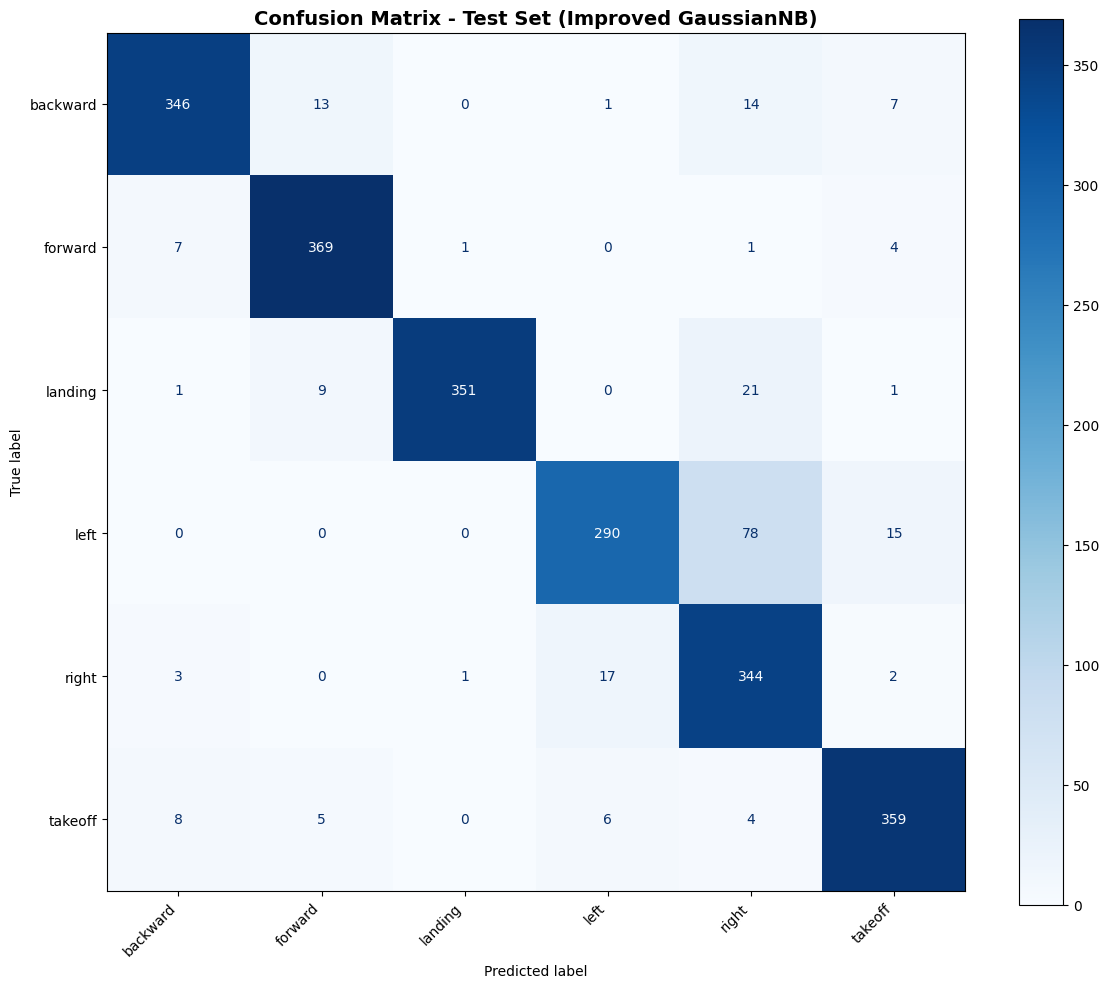

Confusion Matrix visualization completed.


In [76]:
# Generate confusion matrices for test set
cm_test = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm_test, display_labels=label_encoder.classes_).plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix - Test Set (Improved GaussianNB)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Confusion Matrix visualization completed.")

## Step 12: Performance Comparison Across Sets

In [77]:
# Calculate training accuracy
y_train_pred = best_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Performance summary
print("\n" + "="*60)
print("PERFORMANCE SUMMARY - IMPROVED GAUSSIANNAIVE BAYES")
print("="*60)
print(f"\nTraining Set Accuracy:   {train_accuracy:.4f}")
print(f"Validation Set Accuracy: {val_accuracy:.4f}")
print(f"Test Set Accuracy:       {test_accuracy:.4f}")

# Per-class metrics for test set (ensure all labels are included)
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_test_pred,
    labels=np.arange(len(label_encoder.classes_)),
    zero_division=0
)

print(f"\n{'='*60}")
print("PER-CLASS METRICS (TEST SET)")
print(f"{'='*60}")
print(f"{'Class':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<8}")
print("-" * 70)
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name:<15} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f} {support[i]:<8}")
print("-" * 70)
print(f"{'Weighted Avg':<15} {np.average(precision, weights=support):<12.4f} {np.average(recall, weights=support):<12.4f} {np.average(f1, weights=support):<12.4f} {support.sum():<8}")

print(f"\n{'='*60}")
print("IMPROVEMENT SUMMARY")
print(f"{'='*60}")
print(f"Key Improvements Applied:")
print(f"  ✓ Windowing within contiguous label segments")
print(f"  ✓ Time-domain feature extraction (mean, std, min, max, etc.)")
print(f"  ✓ Frequency-domain features (Welch bandpower)")
print(f"  ✓ RobustScaler for preprocessing")
print(f"  ✓ SelectKBest for feature selection ({len(selected_features)} features selected)")
print(f"  ✓ GroupShuffleSplit for group-aware data splitting")
print(f"  ✓ GridSearchCV for var_smoothing hyperparameter tuning")
print(f"  ✓ SimpleImputer for NaN handling")
print(f"  ✓ VarianceThreshold for removing zero-variance features")
print(f"  ✓ Class priors for balanced classification")


PERFORMANCE SUMMARY - IMPROVED GAUSSIANNAIVE BAYES

Training Set Accuracy:   0.9163
Validation Set Accuracy: 0.9149
Test Set Accuracy:       0.9039

PER-CLASS METRICS (TEST SET)
Class           Precision    Recall       F1-Score     Support 
----------------------------------------------------------------------
backward        0.9479       0.9081       0.9276       381     
forward         0.9318       0.9660       0.9486       382     
landing         0.9943       0.9164       0.9538       383     
left            0.9236       0.7572       0.8321       383     
right           0.7446       0.9373       0.8299       367     
takeoff         0.9253       0.9398       0.9325       382     
----------------------------------------------------------------------
Weighted Avg    0.9124       0.9039       0.9046       2278    

IMPROVEMENT SUMMARY
Key Improvements Applied:
  ✓ Windowing within contiguous label segments
  ✓ Time-domain feature extraction (mean, std, min, max, etc.)
  ✓ Freque

## Step 13: Feature Importance Analysis

In [78]:
# Analyze selected features and model parameters
print("Feature Selection and Model Analysis:")
print(f"\nTotal features generated: {X_train.shape[1]}")
print(f"Features selected by SelectKBest: {len(selected_features)}")
print(f"Selection percentage: {100*len(selected_features)/X_train.shape[1]:.1f}%")

print(f"\nTop 30 Selected Features:")
for i, feat in enumerate(selected_features[:30], 1):
    print(f"  {i:2d}. {feat}")

# Extract model parameters
gnb_model = final_pipe.named_steps["gnb"]
print(f"\nGaussianNB Model Parameters:")
print(f"  Classes: {gnb_model.classes_}")
print(f"  Class priors: {gnb_model.class_prior_}")
print(f"  Theta shape (means): {gnb_model.theta_.shape}")
print(f"  Var shape (variances): {gnb_model.var_.shape}")
print(f"  Var smoothing: {gnb_model.var_smoothing}")

# Analyze feature types
feature_type_counts = {}
for feat in selected_features:
    if 'power' in feat or 'relpower' in feat:
        ftype = 'Frequency (Bandpower)'
    elif any(t in feat for t in ['mean', 'std', 'min', 'max', 'ptp', 'rms', 'median', 'q25', 'q75', 'iqr', 'zcr']):
        ftype = 'Time-domain'
    else:
        ftype = 'Other'
    feature_type_counts[ftype] = feature_type_counts.get(ftype, 0) + 1

print(f"\nSelected Features by Type:")
for ftype, count in sorted(feature_type_counts.items(), key=lambda x: -x[1]):
    pct = 100*count/len(selected_features)
    print(f"  {ftype}: {count} features ({pct:.1f}%)")

Feature Selection and Model Analysis:

Total features generated: 336
Features selected by SelectKBest: 60
Selection percentage: 17.9%

Top 30 Selected Features:
   1.  EXG Channel 1_median
   2.  EXG Channel 1_q25
   3.  EXG Channel 1_iqr
   4.  EXG Channel 2_median
   5.  EXG Channel 2_q25
   6.  EXG Channel 2_iqr
   7.  EXG Channel 3_median
   8.  EXG Channel 3_q25
   9.  EXG Channel 3_q75
  10.  EXG Channel 3_iqr
  11.  EXG Channel 3_zcr
  12.  EXG Channel 4_mean
  13.  EXG Channel 4_rms
  14.  EXG Channel 4_median
  15.  EXG Channel 4_q25
  16.  EXG Channel 5_mean
  17.  EXG Channel 5_median
  18.  EXG Channel 5_zcr
  19.  EXG Channel 6_mean
  20.  EXG Channel 6_median
  21.  EXG Channel 6_q25
  22.  EXG Channel 6_q75
  23.  EXG Channel 6_iqr
  24.  EXG Channel 7_mean
  25.  EXG Channel 7_median
  26.  EXG Channel 7_q25
  27.  EXG Channel 7_q75
  28.  EXG Channel 7_iqr
  29.  EXG Channel 7_zcr
  30.  EXG Channel 8_mean

GaussianNB Model Parameters:
  Classes: [0 1 2 3 4 5]
  Class 

## Step 14: Save Model and Artifacts

In [79]:
# Save model and artifacts
model_path = r'C:\Users\shail\NBAlgo\gaussiannb_improved_pipeline.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(final_pipe, f)
print(f"Improved model pipeline saved to: {model_path}")

# Save label encoder
encoder_path = r'C:\Users\shail\NBAlgo\label_encoder_improved.pkl'
with open(encoder_path, 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"Label encoder saved to: {encoder_path}")

# Save configuration
config_path = r'C:\Users\shail\NBAlgo\config_improved.pkl'
with open(config_path, 'wb') as f:
    pickle.dump(CONFIG, f)
print(f"Configuration saved to: {config_path}")

# Save performance metrics
metrics = {
    'train_accuracy': train_accuracy,
    'val_accuracy': val_accuracy,
    'test_accuracy': test_accuracy,
    'label_encoder_classes': label_encoder.classes_.tolist(),
    'selected_features': selected_features.tolist(),
    'num_selected_features': len(selected_features),
    'num_total_features': X_train.shape[1],
    'num_classes': len(label_encoder.classes_),
    'best_var_smoothing': float(search.best_params_['gnb__var_smoothing']),
    'class_priors': {str(k): float(v) for k, v in class_priors_map.items()},
}

metrics_path = r'C:\Users\shail\NBAlgo\model_metrics_improved.pkl'
with open(metrics_path, 'wb') as f:
    pickle.dump(metrics, f)
print(f"Metrics saved to: {metrics_path}")

# Save per-class metrics
per_class_metrics = {
    'classes': label_encoder.classes_.tolist(),
    'precision': precision.tolist(),
    'recall': recall.tolist(),
    'f1': f1.tolist(),
    'support': support.tolist(),
}

per_class_path = r'C:\Users\shail\NBAlgo\per_class_metrics_improved.pkl'
with open(per_class_path, 'wb') as f:
    pickle.dump(per_class_metrics, f)
print(f"Per-class metrics saved to: {per_class_path}")

print("\n✓ All artifacts saved successfully!")

Improved model pipeline saved to: C:\Users\shail\NBAlgo\gaussiannb_improved_pipeline.pkl
Label encoder saved to: C:\Users\shail\NBAlgo\label_encoder_improved.pkl
Configuration saved to: C:\Users\shail\NBAlgo\config_improved.pkl
Metrics saved to: C:\Users\shail\NBAlgo\model_metrics_improved.pkl
Per-class metrics saved to: C:\Users\shail\NBAlgo\per_class_metrics_improved.pkl

✓ All artifacts saved successfully!


## Step 15: Example Predictions

In [80]:
# Make predictions on a few test samples
num_samples = 5
sample_indices = np.random.choice(len(X_test), num_samples, replace=False)

print("\nSample Predictions from Test Set:")
print("="*90)

for idx, sample_idx in enumerate(sample_indices, 1):
    true_label = label_encoder.inverse_transform([y_test[sample_idx]])[0]
    predicted_label = label_encoder.inverse_transform([y_test_pred[sample_idx]])[0]
    confidence = y_test_proba[sample_idx].max()
    
    match = "✓ CORRECT" if true_label == predicted_label else "✗ INCORRECT"
    
    print(f"\nSample {idx}: {match}")
    print(f"  True Label:      {true_label}")
    print(f"  Predicted Label: {predicted_label}")
    print(f"  Confidence:      {confidence:.4f}")
    print(f"  Probabilities:")
    for class_idx, class_name in enumerate(label_encoder.classes_):
        prob = y_test_proba[sample_idx][class_idx]
        bar = "█" * int(prob * 30)
        print(f"    {class_name:<15}: {prob:.4f} {bar}")


Sample Predictions from Test Set:

Sample 1: ✓ CORRECT
  True Label:      right
  Predicted Label: right
  Confidence:      1.0000
  Probabilities:
    backward       : 0.0000 
    forward        : 0.0000 
    landing        : 0.0000 
    left           : 0.0000 
    right          : 1.0000 █████████████████████████████
    takeoff        : 0.0000 

Sample 2: ✓ CORRECT
  True Label:      right
  Predicted Label: right
  Confidence:      1.0000
  Probabilities:
    backward       : 0.0000 
    forward        : 0.0000 
    landing        : 0.0000 
    left           : 0.0000 
    right          : 1.0000 █████████████████████████████
    takeoff        : 0.0000 

Sample 3: ✓ CORRECT
  True Label:      forward
  Predicted Label: forward
  Confidence:      1.0000
  Probabilities:
    backward       : 0.0000 
    forward        : 1.0000 ██████████████████████████████
    landing        : 0.0000 
    left           : 0.0000 
    right          : 0.0000 
    takeoff        : 0.0000 

Sample 4

## Step 16: Confusion Matrix and ROC-AUC Curve

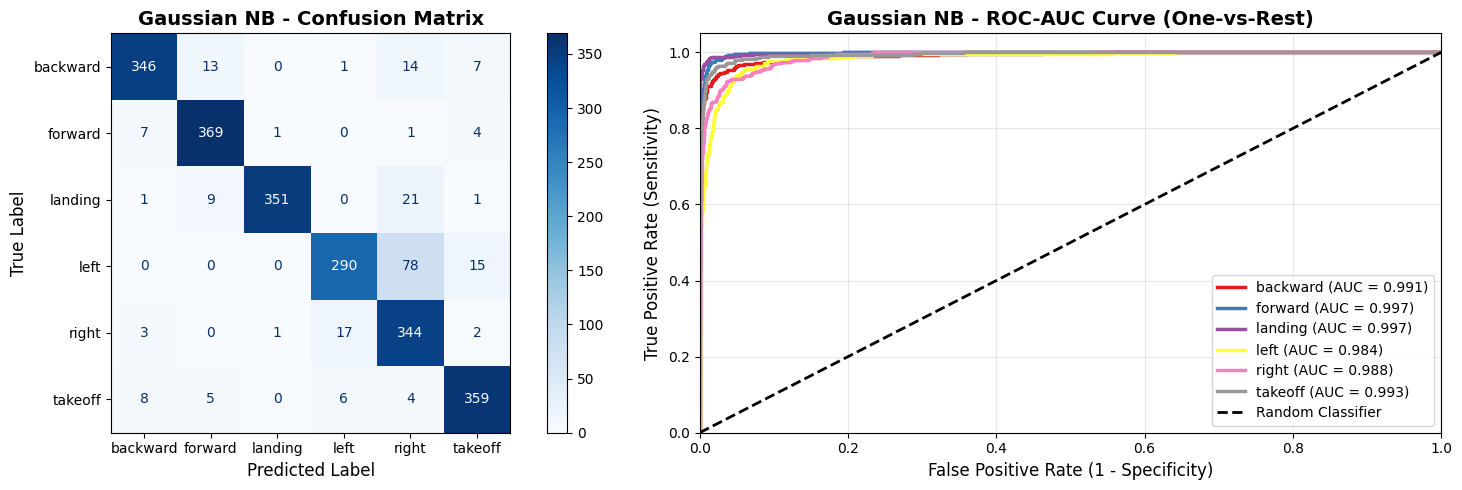


OVERALL TEST SET METRICS
Test Accuracy: 0.9039
Micro-Average AUC: 0.9913
Macro-Average AUC: 0.9917


In [82]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ========== Confusion Matrix ==========
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Gaussian NB - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# ========== ROC-AUC Curve ==========
# For multi-class ROC, we'll plot One-vs-Rest curves
n_classes = len(label_encoder.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

colors = plt.cm.Set1(np.linspace(0, 1, n_classes))

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, lw=2.5,
                 label=f'{label_encoder.classes_[i]} (AUC = {roc_auc:.3f})')

# Plot diagonal line
axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
axes[1].set_title('Gaussian NB - ROC-AUC Curve (One-vs-Rest)', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print overall metrics
print("\n" + "="*60)
print("OVERALL TEST SET METRICS")
print("="*60)
test_accuracy = np.mean(y_test_pred == y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Compute micro and macro AUC
try:
    micro_auc = roc_auc_score(y_test_bin, y_test_proba, multi_class='ovr', average='micro')
    macro_auc = roc_auc_score(y_test_bin, y_test_proba, multi_class='ovr', average='macro')
    print(f"Micro-Average AUC: {micro_auc:.4f}")
    print(f"Macro-Average AUC: {macro_auc:.4f}")
except:
    print("Note: AUC computation requires multiple classes")